# Multi-Channel 1D-CNN with LSTM

## Loading Data

In [20]:
from pathlib import Path
import torch

DATA_DIR = Path("PatchTst/tensor_exports/eeg")  # adjust if needed

x_train = torch.load(DATA_DIR / "x_eeg_train.pt")
y_train = torch.load(DATA_DIR / "y_eeg_train.pt")

x_val = torch.load(DATA_DIR / "x_eeg_val.pt")
y_val = torch.load(DATA_DIR / "y_eeg_val.pt")

x_test = torch.load(DATA_DIR / "x_eeg_test.pt")
y_test = torch.load(DATA_DIR / "y_eeg_test.pt")

print(x_train.shape, y_train.shape)

torch.Size([136122, 3, 1600]) torch.Size([136122])


In [21]:
from torch.utils.data import TensorDataset, DataLoader

# Labels should be float for BCE
y_train = y_train.float()
y_val   = y_val.float()
y_test  = y_test.float()

train_loader = DataLoader(TensorDataset(x_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(TensorDataset(x_val, y_val), batch_size=32)
test_loader  = DataLoader(TensorDataset(x_test, y_test), batch_size=32)

## CNN Model

In [3]:
import torch.nn as nn

class MultiChannelCNN(nn.Module):
    def __init__(self):
        super().__init__()

        self.conv1 = nn.Conv1d(3, 32, kernel_size=5, padding=2)
        self.bn1   = nn.BatchNorm1d(32)

        self.conv2 = nn.Conv1d(32, 64, kernel_size=5, padding=2)
        self.bn2   = nn.BatchNorm1d(64)
        self.pool1 = nn.MaxPool1d(2)

        self.conv3 = nn.Conv1d(64, 128, kernel_size=3, padding=1)
        self.bn3   = nn.BatchNorm1d(128)
        self.pool2 = nn.MaxPool1d(2)

        self.conv4 = nn.Conv1d(128, 256, kernel_size=3, padding=1)
        self.bn4   = nn.BatchNorm1d(256)
        self.pool3 = nn.MaxPool1d(2)

        self.dropout = nn.Dropout(0.3)

        # LSTM
        self.lstm = nn.LSTM(input_size=256, hidden_size=128, batch_first=True)

        self.fc1 = nn.Linear(128, 64)
        self.fc2 = nn.Linear(64, 1)

    def forward(self, x):
        # x: (batch, 3, 1600)

        x = torch.relu(self.bn1(self.conv1(x)))
        x = torch.relu(self.bn2(self.conv2(x)))
        x = self.pool1(x)

        x = torch.relu(self.bn3(self.conv3(x)))
        x = self.pool2(x)

        x = torch.relu(self.bn4(self.conv4(x)))
        x = self.pool3(x)

        x = self.dropout(x)

        # (batch, channels, seq) → (batch, seq, channels)
        x = x.permute(0, 2, 1)

        _, (h, _) = self.lstm(x)
        x = h[-1]

        x = torch.relu(self.fc1(x))
        x = self.fc2(x)  # logits

        return x.squeeze(-1)

## Training

In [5]:
device = "cuda" if torch.cuda.is_available() else "cpu"

model = MultiChannelCNN().to(device)

# Class imbalance handling
pos_weight = (y_train == 0).sum() / (y_train == 1).sum()
pos_weight = torch.tensor([pos_weight], device=device)

criterion = nn.BCEWithLogitsLoss(pos_weight=pos_weight)
optimizer = torch.optim.Adam(model.parameters(), lr=1e-4)

NameError: name 'y_train' is not defined

In [24]:
best_val_loss = float('inf')
patience = 5          # number of epochs to wait
counter = 0           # how many epochs since improvement

for epoch in range(50):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        optimizer.zero_grad()

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_train_loss = total_loss / len(train_loader)

    model.eval()
    val_loss = 0

    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            logits = model(X_batch)
            loss = criterion(logits, y_batch)

            val_loss += loss.item()

    avg_val_loss = val_loss / len(val_loader)

    # ===== SAVE BEST MODEL =====
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "cnn_eeg_best.pt")
        print("✅ Saved new best model")
        counter = 0  # reset patience counter
    else:
        counter += 1
        print(f"⚠️ No improvement ({counter}/{patience})")

    print(f"Epoch {epoch+1}")
    print(f"  Train Loss: {avg_train_loss:.4f}")
    print(f"  Val Loss:   {avg_val_loss:.4f}")

    # ===== EARLY STOPPING =====
    if counter >= patience:
        print("⏹️ Early stopping triggered")
        break

✅ Saved new best model
Epoch 1
  Train Loss: 0.2787
  Val Loss:   0.1167
✅ Saved new best model
Epoch 2
  Train Loss: 0.1497
  Val Loss:   0.1059
✅ Saved new best model
Epoch 3
  Train Loss: 0.1204
  Val Loss:   0.0950
⚠️ No improvement (1/5)
Epoch 4
  Train Loss: 0.1068
  Val Loss:   0.1050
✅ Saved new best model
Epoch 5
  Train Loss: 0.0987
  Val Loss:   0.0690
✅ Saved new best model
Epoch 6
  Train Loss: 0.0872
  Val Loss:   0.0591
✅ Saved new best model
Epoch 7
  Train Loss: 0.0815
  Val Loss:   0.0572
✅ Saved new best model
Epoch 8
  Train Loss: 0.0727
  Val Loss:   0.0477
⚠️ No improvement (1/5)
Epoch 9
  Train Loss: 0.0702
  Val Loss:   0.0641
⚠️ No improvement (2/5)
Epoch 10
  Train Loss: 0.0692
  Val Loss:   0.1006
✅ Saved new best model
Epoch 11
  Train Loss: 0.0663
  Val Loss:   0.0373
⚠️ No improvement (1/5)
Epoch 12
  Train Loss: 0.0598
  Val Loss:   0.0592
✅ Saved new best model
Epoch 13
  Train Loss: 0.0575
  Val Loss:   0.0371
⚠️ No improvement (1/5)
Epoch 14
  Train Lo

## Evaluation

In [26]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    RocCurveDisplay,
    PrecisionRecallDisplay
)
import matplotlib.pyplot as plt
import numpy as np

model.eval()

all_preds = []
all_labels = []
all_probs = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:   # use train_loader / valid_loader / test_loader
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

# Flatten everything
all_preds = np.concatenate(all_preds).flatten()
all_labels = np.concatenate(all_labels).flatten()
all_probs = np.concatenate(all_probs).flatten()

# Metrics
precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels, all_preds, average='binary', zero_division=0
)

accuracy = (all_preds == all_labels).mean()

try:
    auroc = roc_auc_score(all_labels, all_probs)
except ValueError:
    auroc = float('nan')

try:
    auprc = average_precision_score(all_labels, all_probs)
except ValueError:
    auprc = float('nan')

print("=" * 50)
print("EVALUATION RESULTS")
print("=" * 50)
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1 Score : {f1:.4f}")
print(f"AUROC    : {auroc:.4f}")
print(f"AUPRC    : {auprc:.4f}")
print("=" * 50)

EVALUATION RESULTS
Accuracy : 0.9969
Precision: 0.9750
Recall   : 0.9811
F1 Score : 0.9781
AUROC    : 0.9999
AUPRC    : 0.9981


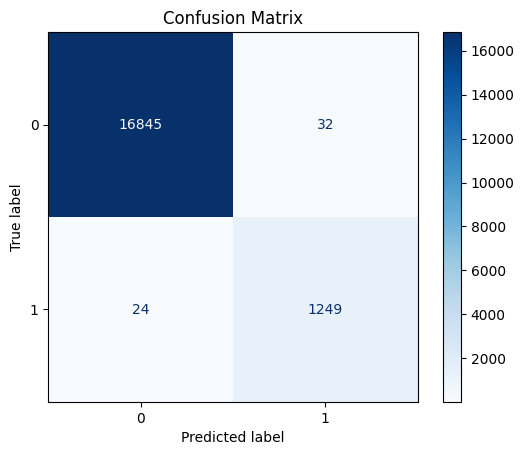

In [27]:
cm = confusion_matrix(all_labels, all_preds)
disp = ConfusionMatrixDisplay(confusion_matrix=cm)

disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix")
plt.show()

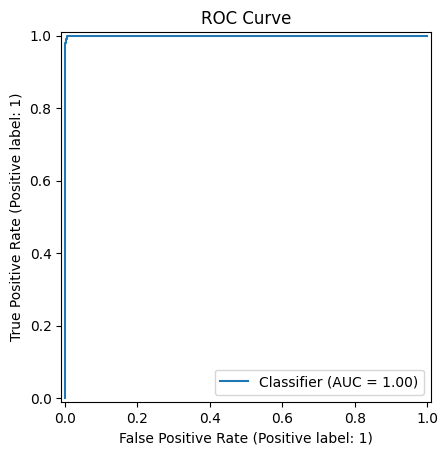

In [28]:
RocCurveDisplay.from_predictions(all_labels, all_probs)
plt.title("ROC Curve")
plt.show()

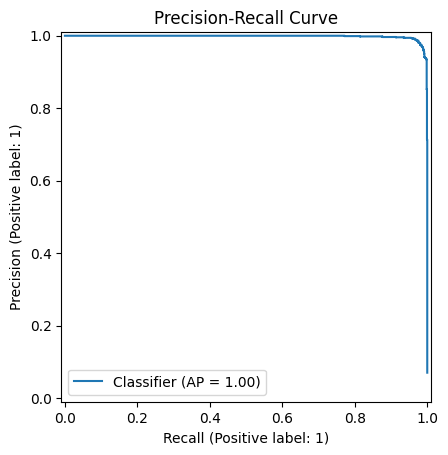

In [29]:
PrecisionRecallDisplay.from_predictions(all_labels, all_probs)
plt.title("Precision-Recall Curve")
plt.show()

# Finetuning on ECoG Data

## Load Model

In [31]:
model = MultiChannelCNN().to(device)
model.load_state_dict(torch.load("cnn_eeg_best.pt"))

<All keys matched successfully>

## Load Data

In [8]:
import torch
from torch.utils.data import TensorDataset, DataLoader

# Load the saved file
data = torch.load("ecog_tensors.pt", weights_only=False)

# Extract tensors
x_ecog_train = data["X_train"]   # shape: (N, 1600, 1)
y_ecog_train = data["y_train"]
x_ecog_val   = data["X_valid"]
y_ecog_val   = data["y_valid"]
x_ecog_test  = data["X_test"]
y_ecog_test  = data["y_test"]

x_ecog_train = torch.tensor(x_ecog_train, dtype=torch.float32)
y_ecog_train = torch.tensor(y_ecog_train, dtype=torch.float32)

x_ecog_val = torch.tensor(x_ecog_val, dtype=torch.float32)
y_ecog_val = torch.tensor(y_ecog_val, dtype=torch.float32)

x_ecog_test = torch.tensor(x_ecog_test, dtype=torch.float32)
y_ecog_test = torch.tensor(y_ecog_test, dtype=torch.float32)


# Create PyTorch datasets
train_dataset = TensorDataset(x_ecog_train, y_ecog_train)
val_dataset   = TensorDataset(x_ecog_val, y_ecog_val)
test_dataset  = TensorDataset(x_ecog_test, y_ecog_test)

# DataLoaders
train_ecog_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_ecog_loader   = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_ecog_loader  = DataLoader(test_dataset, batch_size=64, shuffle=False)

print("hello")
print("Train batches:", len(train_ecog_loader), "Val batches:", len(val_ecog_loader), "Test batches:", len(test_ecog_loader))

hello
Train batches: 110 Val batches: 22 Test batches: 15


## Freezing Strategies

In [21]:
def freeze_layers(model, strategy):
    # First unfreeze everything
    for param in model.parameters():
        param.requires_grad = True

    if strategy == "freeze_none":
        pass

    elif strategy == "freeze_conv1":
        for param in model.conv1.parameters():
            param.requires_grad = False
        for param in model.bn1.parameters():
            param.requires_grad = False

    elif strategy == "freeze_conv12":
        for layer in [model.conv1, model.bn1, model.conv2, model.bn2]:
            for param in layer.parameters():
                param.requires_grad = False

    elif strategy == "freeze_all_cnn":
        for layer in [
            model.conv1, model.bn1,
            model.conv2, model.bn2,
            model.conv3, model.bn3,
            model.conv4, model.bn4
        ]:
            for param in layer.parameters():
                param.requires_grad = False

    elif strategy == "freeze_all_except_fc":
        for param in model.parameters():
            param.requires_grad = False
        for param in model.fc1.parameters():
            param.requires_grad = True
        for param in model.fc2.parameters():
            param.requires_grad = True

## Training Function

In [43]:
def train_finetune(model, train_ecog_loader, val_ecog_loader, strategy, epochs=20, patience=10):
    freeze_layers(model, strategy)

    optimizer = torch.optim.Adam(
        filter(lambda p: p.requires_grad, model.parameters()),
        lr=5e-5  # small LR for finetuning
    )

    criterion = nn.BCEWithLogitsLoss()

    best_val_recall = 0.0
    epochs_no_improve = 0

    for epoch in range(epochs):
        # ===== TRAIN =====
        model.train()
        train_loss = 0

        for X_batch, y_batch in train_ecog_loader:
            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            loss.backward()
            optimizer.step()

            train_loss += loss.item()

        train_loss /= len(train_ecog_loader)

        # ===== VALIDATE =====
        model.eval()
        val_loss = 0
        all_preds = []
        all_labels = []

        with torch.no_grad():
            for X_batch, y_batch in val_ecog_loader:
                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)
        
                logits = model(X_batch)
        
                logits = logits.view(-1)
                y_batch = y_batch.view(-1).float()
        
                loss = criterion(logits, y_batch)
                val_loss += loss.item() * X_batch.size(0)
        
                probs = torch.sigmoid(logits)
                preds = (probs > 0.5).float()
        
                all_preds.append(preds.cpu().numpy())
                all_labels.append(y_batch.cpu().numpy())

        val_loss /= len(val_ecog_loader.dataset)

        all_preds = np.concatenate(all_preds)
        all_labels = np.concatenate(all_labels)
        
        val_recall = recall_score(all_labels, all_preds, zero_division=0)

        if val_recall > best_val_recall:
            best_val_recall = val_recall
            torch.save(model.state_dict(), f"best_model_{strategy}.pt")
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epochs_no_improve >= patience:
            print(f"Early stopping at epoch {epoch+1}")
            break

        print(f"Val Loss: {val_loss:.4f} | Val Recall: {val_recall:.4f}")

    return best_val_recall

## Freezing Experiments

In [44]:
strategies = [
    "freeze_none",
    "freeze_conv1",
    "freeze_conv12",
    "freeze_all_cnn",
    "freeze_all_except_fc"
]

results = {}

for strategy in strategies:
    print(f"\n Running strategy: {strategy}")

    model = MultiChannelCNN().to(device)
    model.load_state_dict(torch.load("cnn_eeg_best.pt"))

    best_val_recall = train_finetune(
        model,
        train_ecog_loader,
        val_ecog_loader,
        strategy,
        epochs=20
    )

    results[strategy] = best_val_recall


 Running strategy: freeze_none
Val Loss: 0.4695 | Val Recall: 0.6678
Val Loss: 0.8063 | Val Recall: 0.3715
Val Loss: 0.3160 | Val Recall: 0.8036
Val Loss: 0.2601 | Val Recall: 0.8543
Val Loss: 0.2413 | Val Recall: 0.8625
Val Loss: 0.2593 | Val Recall: 0.8412
Val Loss: 0.2509 | Val Recall: 0.8331
Val Loss: 0.3672 | Val Recall: 0.6743
Val Loss: 0.3313 | Val Recall: 0.7676
Val Loss: 0.4778 | Val Recall: 0.6383
Val Loss: 0.2208 | Val Recall: 0.8805
Val Loss: 0.3893 | Val Recall: 0.6989
Val Loss: 0.1885 | Val Recall: 0.9378
Val Loss: 0.8708 | Val Recall: 0.3633
Val Loss: 0.5389 | Val Recall: 0.5941
Val Loss: 0.8312 | Val Recall: 0.3895
Val Loss: 0.1802 | Val Recall: 0.9264
Val Loss: 0.5056 | Val Recall: 0.6203
Val Loss: 0.1739 | Val Recall: 0.9329
Val Loss: 0.1750 | Val Recall: 0.9313

 Running strategy: freeze_conv1
Val Loss: 0.4634 | Val Recall: 0.7119
Val Loss: 0.3046 | Val Recall: 0.8298
Val Loss: 0.6114 | Val Recall: 0.5188
Val Loss: 0.2434 | Val Recall: 0.8674
Val Loss: 0.3555 | Val 

In [45]:
sorted_results = sorted(results.items(), key=lambda x: x[1], reverse=True)

print("\n FINAL RESULTS (sorted by recall):")
print("=" * 40)

for strategy, recall in sorted_results:
    print(f"{strategy:25s} → Recall: {recall:.4f}")


 FINAL RESULTS (sorted by recall):
freeze_none               → Recall: 0.9378
freeze_conv1              → Recall: 0.9280
freeze_all_cnn            → Recall: 0.9198
freeze_conv12             → Recall: 0.9116
freeze_all_except_fc      → Recall: 0.6367


## Evaluation

In [46]:
model = MultiChannelCNN().to(device)
model.load_state_dict(torch.load("finetune_freeze_none.pt"))  # change if needed
model.eval()

MultiChannelCNN(
  (conv1): Conv1d(3, 32, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn1): BatchNorm1d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (conv2): Conv1d(32, 64, kernel_size=(5,), stride=(1,), padding=(2,))
  (bn2): BatchNorm1d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool1): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv3): Conv1d(64, 128, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn3): BatchNorm1d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool2): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (conv4): Conv1d(128, 256, kernel_size=(3,), stride=(1,), padding=(1,))
  (bn4): BatchNorm1d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (pool3): MaxPool1d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout): Dropout(p=0.3, inplace=False)
  (lstm): LSTM(256, 128, batch_first=T

In [47]:
from sklearn.metrics import (
    precision_recall_fscore_support,
    roc_auc_score,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    precision_recall_curve
)
import matplotlib.pyplot as plt

all_preds = []
all_labels = []
all_probs = []

test_loss = 0.0

criterion = nn.BCEWithLogitsLoss()

with torch.no_grad():
    for X_batch, y_batch in test_ecog_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        logits = model(X_batch)
        loss = criterion(logits, y_batch)

        probs = torch.sigmoid(logits)
        preds = (probs > 0.5).long()

        test_loss += loss.item()

        all_preds.append(preds.cpu().numpy())
        all_labels.append(y_batch.cpu().numpy())
        all_probs.append(probs.cpu().numpy())

# Flatten everything
all_preds_flat = np.concatenate([p.flatten() for p in all_preds])
all_labels_flat = np.concatenate([l.flatten() for l in all_labels])
all_probs_flat = np.concatenate([p.flatten() for p in all_probs])

# Metrics
accuracy = (all_preds_flat == all_labels_flat).mean()

precision, recall, f1, _ = precision_recall_fscore_support(
    all_labels_flat,
    all_preds_flat,
    average='binary',
    zero_division=0
)

# AUROC
try:
    auroc = roc_auc_score(all_labels_flat, all_probs_flat)
except:
    auroc = float('nan')

# AUPRC
try:
    auprc = average_precision_score(all_labels_flat, all_probs_flat)
except:
    auprc = float('nan')

print("=" * 50)
print("ECOG TEST RESULTS")
print("=" * 50)
print(f"Loss: {test_loss/len(test_ecog_loader):.4f}")
print(f"Accuracy: {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall: {recall:.4f}")
print(f"F1 Score: {f1:.4f}")
print(f"AUROC: {auroc:.4f}")
print(f"AUPRC: {auprc:.4f}")
print("=" * 50)

ECOG TEST RESULTS
Loss: 0.2111
Accuracy: 0.9070
Precision: 0.9420
Recall: 0.8378
F1 Score: 0.8869
AUROC: 0.9747
AUPRC: 0.9678


<Figure size 500x400 with 0 Axes>

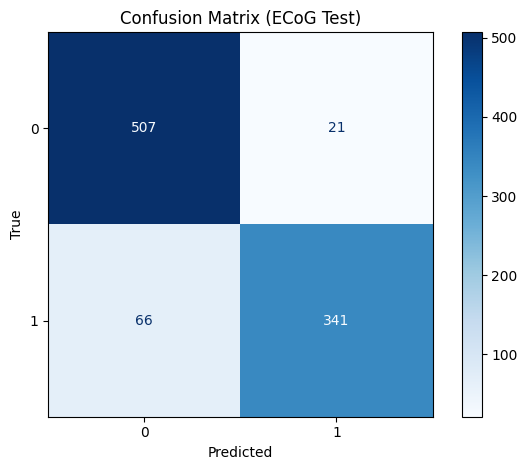

In [48]:
cm = confusion_matrix(all_labels_flat, all_preds_flat, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (ECoG Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

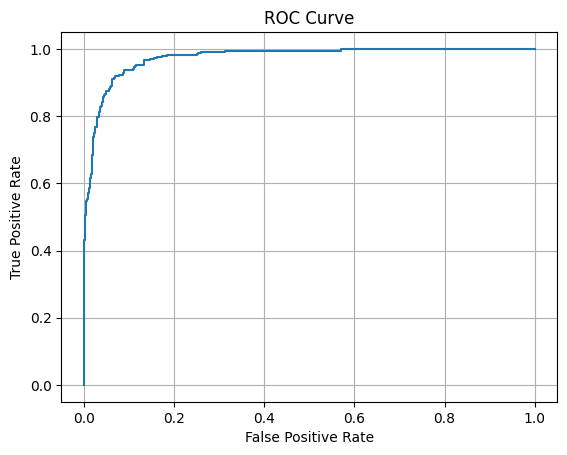

In [49]:
fpr, tpr, _ = roc_curve(all_labels_flat, all_probs_flat)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

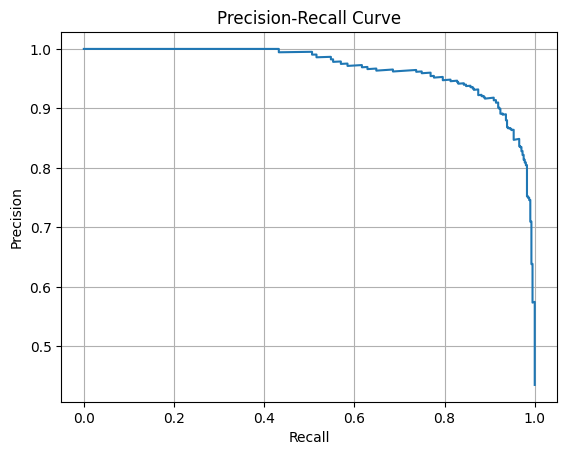

In [50]:
precision_curve, recall_curve, _ = precision_recall_curve(all_labels_flat, all_probs_flat)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()

# ECoG Only

## Training

In [36]:
import torch
import torch.nn as nn
import torch.optim as optim

device = "cuda" if torch.cuda.is_available() else "cpu"
model = MultiChannelCNN().to(device)

criterion = nn.BCEWithLogitsLoss()  # works with raw logits
optimizer = optim.Adam(model.parameters(), lr=1e-3)

num_epochs = 50
best_val_loss = float('inf')

for epoch in range(num_epochs):
    model.train()
    total_loss = 0

    for X_batch, y_batch in train_ecog_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        logits = model(X_batch)
        loss = criterion(logits, y_batch)
        loss.backward()
        optimizer.step()

        total_loss += loss.item() * X_batch.size(0)

    avg_train_loss = total_loss / len(train_ecog_loader.dataset)

    # --- Validation ---
    model.eval()
    val_loss = 0
    with torch.no_grad():
        for X_batch, y_batch in val_ecog_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            loss = criterion(logits, y_batch)
            val_loss += loss.item() * X_batch.size(0)

    avg_val_loss = val_loss / len(val_ecog_loader.dataset)

    # --- Save best model ---
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save(model.state_dict(), "cnn_lstm_ecog_best.pt")

    print(f"Epoch {epoch+1}/{num_epochs} | Train Loss: {avg_train_loss:.4f} | Val Loss: {avg_val_loss:.4f}")

Epoch 1/50 | Train Loss: 0.3333 | Val Loss: 0.2316
Epoch 2/50 | Train Loss: 0.2495 | Val Loss: 0.2480
Epoch 3/50 | Train Loss: 0.2325 | Val Loss: 0.3040
Epoch 4/50 | Train Loss: 0.2249 | Val Loss: 0.2640
Epoch 5/50 | Train Loss: 0.2160 | Val Loss: 0.2741
Epoch 6/50 | Train Loss: 0.2069 | Val Loss: 0.2647
Epoch 7/50 | Train Loss: 0.1912 | Val Loss: 0.2195
Epoch 8/50 | Train Loss: 0.1871 | Val Loss: 0.2499
Epoch 9/50 | Train Loss: 0.1892 | Val Loss: 1.0262
Epoch 10/50 | Train Loss: 0.1784 | Val Loss: 0.2535
Epoch 11/50 | Train Loss: 0.1868 | Val Loss: 0.2074
Epoch 12/50 | Train Loss: 0.1729 | Val Loss: 0.1982
Epoch 13/50 | Train Loss: 0.1724 | Val Loss: 0.1839
Epoch 14/50 | Train Loss: 0.1660 | Val Loss: 0.3069
Epoch 15/50 | Train Loss: 0.1684 | Val Loss: 0.1629
Epoch 16/50 | Train Loss: 0.1672 | Val Loss: 0.1730
Epoch 17/50 | Train Loss: 0.1724 | Val Loss: 0.1627
Epoch 18/50 | Train Loss: 0.1603 | Val Loss: 1.0356
Epoch 19/50 | Train Loss: 0.1588 | Val Loss: 0.1785
Epoch 20/50 | Train L

## Evaluation

In [37]:
import torch
import numpy as np
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score, 
    confusion_matrix, roc_auc_score, average_precision_score
)

# Load best saved model
model.load_state_dict(torch.load("cnn_lstm_ecog_best.pt"))
model.eval()

def evaluate_model_full(model, data_loader, device):
    y_true = []
    y_probs = []  # store probabilities for AUC

    with torch.no_grad():
        for X_batch, y_batch in data_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            logits = model(X_batch)
            probs = torch.sigmoid(logits)          # convert logits to probabilities
            y_true.extend(y_batch.cpu().numpy())
            y_probs.extend(probs.cpu().numpy())

    y_true = np.array(y_true).flatten()
    y_probs = np.array(y_probs).flatten()
    y_pred = (y_probs >= 0.5).astype(float)

    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, zero_division=0)
    recall = recall_score(y_true, y_pred, zero_division=0)
    f1 = f1_score(y_true, y_pred, zero_division=0)
    cm = confusion_matrix(y_true, y_pred)

    # AUC metrics
    try:
        roc_auc = roc_auc_score(y_true, y_probs)
        pr_auc = average_precision_score(y_true, y_probs)
    except ValueError:
        roc_auc = None
        pr_auc = None

    return {
        "accuracy": accuracy,
        "precision": precision,
        "recall": recall,
        "f1": f1,
        "confusion_matrix": cm,
        "roc_auc": roc_auc,
        "pr_auc": pr_auc
    }

# Evaluate on train, validation, and test sets
train_metrics = evaluate_model_full(model, train_ecog_loader, device)
val_metrics   = evaluate_model_full(model, val_ecog_loader, device)
test_metrics  = evaluate_model_full(model, test_ecog_loader, device)

# Print nicely
def print_metrics(name, metrics):
    print(f"\n{name} Metrics:")
    print(f"Accuracy: {metrics['accuracy']:.4f}")
    print(f"Precision: {metrics['precision']:.4f}")
    print(f"Recall: {metrics['recall']:.4f}")
    print(f"F1 Score: {metrics['f1']:.4f}")
    print(f"ROC-AUC: {metrics['roc_auc']:.4f}" if metrics['roc_auc'] is not None else "ROC-AUC: N/A")
    print(f"PR-AUC: {metrics['pr_auc']:.4f}" if metrics['pr_auc'] is not None else "PR-AUC: N/A")
    print(f"Confusion Matrix:\n{metrics['confusion_matrix']}")

print_metrics("Train", train_metrics)
print_metrics("Validation", val_metrics)
print_metrics("Test", test_metrics)


Train Metrics:
Accuracy: 0.9639
Precision: 0.9362
Recall: 0.9843
F1 Score: 0.9596
ROC-AUC: 0.9961
PR-AUC: 0.9949
Confusion Matrix:
[[3748  205]
 [  48 3007]]

Validation Metrics:
Accuracy: 0.9479
Precision: 0.9190
Recall: 0.9656
F1 Score: 0.9417
ROC-AUC: 0.9885
PR-AUC: 0.9835
Confusion Matrix:
[[738  52]
 [ 21 590]]

Test Metrics:
Accuracy: 0.9561
Precision: 0.9276
Recall: 0.9754
F1 Score: 0.9509
ROC-AUC: 0.9893
PR-AUC: 0.9870
Confusion Matrix:
[[497  31]
 [ 10 397]]


<Figure size 500x400 with 0 Axes>

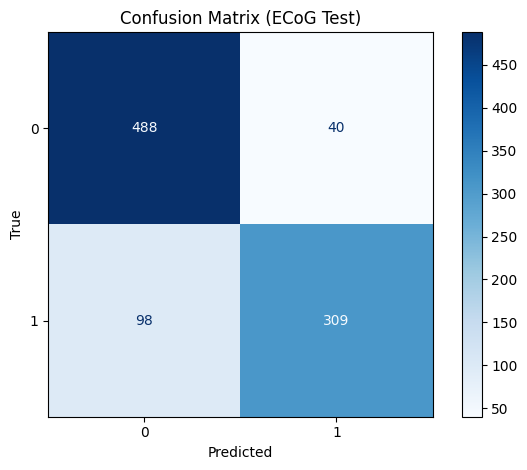

In [38]:
cm = confusion_matrix(all_labels_flat, all_preds_flat, labels=[0, 1])
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[0, 1])

plt.figure(figsize=(5, 4))
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix (ECoG Test)")
plt.xlabel("Predicted")
plt.ylabel("True")
plt.tight_layout()
plt.show()

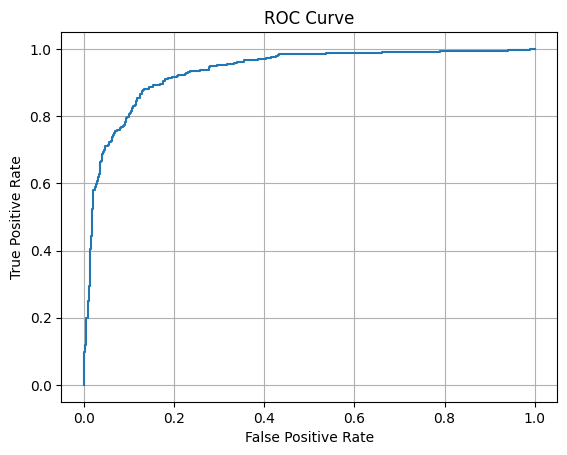

In [39]:
fpr, tpr, _ = roc_curve(all_labels_flat, all_probs_flat)

plt.figure()
plt.plot(fpr, tpr)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")
plt.grid()
plt.show()

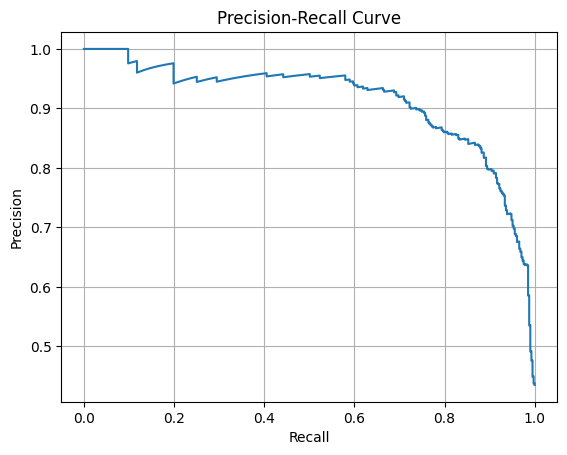

In [40]:
precision_curve, recall_curve, _ = precision_recall_curve(all_labels_flat, all_probs_flat)

plt.figure()
plt.plot(recall_curve, precision_curve)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.grid()
plt.show()